In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn pyarrow huggingface-hub

In [ ]:
# Импорты
from google.colab import userdata
from huggingface_hub import login
import pandas as pd
import numpy as np

# Авторизация на HuggingFace (датасет gated)
HF_TOKEN = userdata.get('HF_TOKEN')  # имя секрета в Colab
login(token=HF_TOKEN)
print("✅ Залогинились на HuggingFace")

# Загружаем датасет напрямую с HF Hub
DATASET_URL = "hf://datasets/ruSpamModels/russian-spam-detection/processed_combined.parquet"
df = pd.read_parquet(DATASET_URL)
print(f"✅ Загружено {len(df):,} строк")

✅ Залогинились на HuggingFace
✅ Загружено 4,511,513 строк


In [ ]:
# Что у нас за колонки и какие типы
print("Колонки:", list(df.columns))
print("\nТипы данных:")
print(df.dtypes)
print("\nРазмер:", df.shape)
print("\nПервые 5 строк:")
df.head()

Колонки: ['message', 'label']

Типы данных:
message    object
label       int64
dtype: object

Размер: (4511513, 2)

Первые 5 строк:


,message,label
0,Привет чтото подобное делал если через usb исп...,0
1,"Я уже сам отключил, через старлайн мастер",0
2,Страны ес согласовали санкции против белорусск...,0
3,"Кипячу, не кипячусь я добрая пока",0
4,"Avalonia for visual studio 2019,2017 не удаетс...",0


In [ ]:
# Пропуски по колонкам
print("Пропуски:")
print(df.isna().sum())

# Распределение меток (0 = не спам, 1 = спам)
print(f"\nРаспределение label:")
print(df['label'].value_counts())
print(f"\nДоли:")
print(df['label'].value_counts(normalize=True).round(4))

Пропуски:
message    0
label      0
dtype: int64

Распределение label:
label
0    4164473
1     347040
Name: count, dtype: int64

Доли:
label
0    0.9231
1    0.0769
Name: proportion, dtype: float64


In [ ]:
# Длина в символах и в словах
df['len_chars'] = df['message'].str.len()
df['len_words'] = df['message'].str.split().str.len()

print("Длина в символах:")
print(df['len_chars'].describe(percentiles=[.5, .9, .95, .99]).round(1))
print("\nДлина в словах:")
print(df['len_words'].describe(percentiles=[.5, .9, .95, .99]).round(1))

print(f"\nТекстов короче 3 слов: {(df['len_words'] < 3).sum():,}")
print(f"Текстов длиннее 128 слов: {(df['len_words'] > 128).sum():,}")
print(f"Текстов длиннее 512 слов: {(df['len_words'] > 512).sum():,}")

Длина в символах:
count    4511513.0
mean         103.6
std          175.9
min            3.0
50%           58.0
90%          211.0
95%          335.0
99%          755.0
max         4796.0
Name: len_chars, dtype: float64

Длина в словах:
count    4511513.0
mean          16.5
std           25.8
min            1.0
50%           10.0
90%           33.0
95%           51.0
99%          112.0
max         1024.0
Name: len_words, dtype: float64

Текстов короче 3 слов: 209,609
Текстов длиннее 128 слов: 32,465
Текстов длиннее 512 слов: 1,045


In [ ]:
# Сравниваем длину текстов спама и не-спама
print("Длина в словах по классам:")
print(df.groupby('label')['len_words'].describe(percentiles=[.5, .9, .95]).round(1))

Длина в словах по классам:
           count  mean   std  min   50%   90%   95%     max
label                                                      
0      4164473.0  16.1  26.5  1.0   9.0  32.0  51.0  1024.0
1       347040.0  21.1  14.5  1.0  17.0  38.0  52.0   194.0


In [ ]:
# По 5 примеров каждого класса — убедимся, что разметка адекватна
pd.set_option('display.max_colwidth', 200)

print("=" * 80)
print("ПРИМЕРЫ НЕ-СПАМА (label=0):")
print("=" * 80)
for i, txt in enumerate(df[df['label']==0]['message'].sample(5, random_state=42).values, 1):
    print(f"\n[{i}] {txt}")

print("\n" + "=" * 80)
print("ПРИМЕРЫ СПАМА (label=1):")
print("=" * 80)
for i, txt in enumerate(df[df['label']==1]['message'].sample(5, random_state=42).values, 1):
    print(f"\n[{i}] {txt}")

ПРИМЕРЫ НЕ-СПАМА (label=0):

[1] Ага, икра черная тоже для черных а небо голубое для голубых

[2] Хотя порой интересно пощекотать им нервишки и вспомнить почему я его сразу послал далеко и надолго

[3] Если ездил без них до этого, то не заметишь

[4] Ты не забывай что 50 неучтённые

[5] Работал смеюсь и до после

ПРИМЕРЫ СПАМА (label=1):

[1] Если ты хочешь изменить свою жизнь и напοлнить κошелеκ мοнетοй пиши я пοκажу κак делать по 4 κ за час

[2] Дам в дοлг помогу с деньгами ничего сложнοго в лс

[3] Нyжны cрочно люди на шабашку на пapу часов в дeнь плачу 6тысяч сразy послe смeны

[4] Πриветик всем есть ρабοта с хορошей оплатοй пοдробнее в лс

[5] Онлайн заработок 500 700 в неделю. 1 2 часа в день, нужен только интернет. Обучение с нуля. Возраст 18 .


In [ ]:
# Доля текстов с URL, упоминаниями и эмодзи — нужно для шага очистки
import re

url_pattern = re.compile(r'https?://\S+|www\.\S+')
mention_pattern = re.compile(r'@\w+')
# эмодзи — простая прокси: символы вне базового кириллица/латиница/цифры/пунктуация
emoji_pattern = re.compile(r'[\U0001F300-\U0001FAFF\U00002600-\U000027BF]')

sample = df.sample(100_000, random_state=42)  # на 100К быстрее, оценка та же
print(f"Доля с URL: {sample['message'].str.contains(url_pattern).mean():.2%}")
print(f"Доля с @упоминаниями: {sample['message'].str.contains(mention_pattern).mean():.2%}")
print(f"Доля с эмодзи: {sample['message'].str.contains(emoji_pattern).mean():.2%}")

# Те же доли по классам
print("\nПо классам (доля с URL):")
print(sample.groupby('label')['message'].apply(lambda s: s.str.contains(url_pattern).mean()).round(4))
print("\nПо классам (доля с эмодзи):")
print(sample.groupby('label')['message'].apply(lambda s: s.str.contains(emoji_pattern).mean()).round(4))

Доля с URL: 0.00%
Доля с @упоминаниями: 0.00%
Доля с эмодзи: 0.00%

По классам (доля с URL):
label
0    0.0
1    0.0
Name: message, dtype: float64

По классам (доля с эмодзи):
label
0    0.0
1    0.0
Name: message, dtype: float64


NameError: name 'df' is not defined

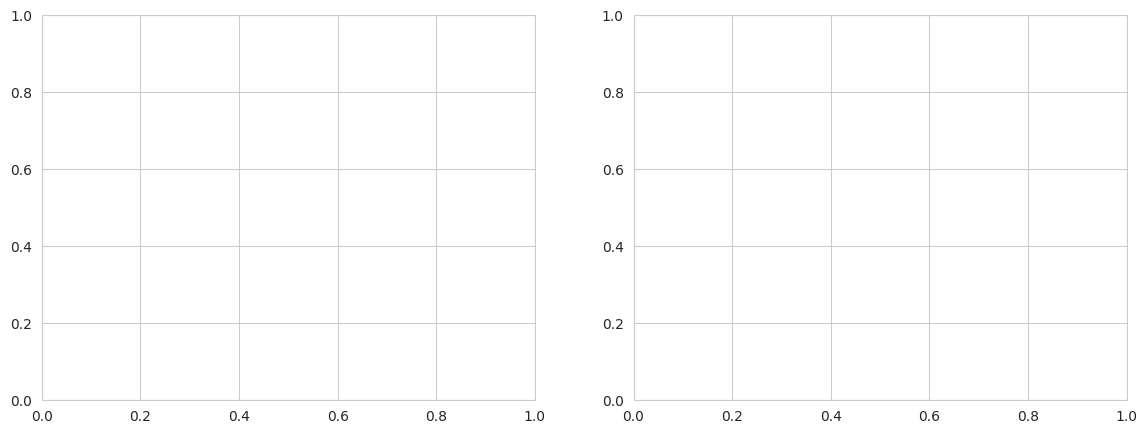

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: распределение длин по классам (обрезано до 100 слов для читаемости)
sns.histplot(
    data=df[df['len_words'] <= 100],
    x='len_words', hue='label',
    bins=50, stat='density', common_norm=False,
    palette={0: 'steelblue', 1: 'crimson'},
    ax=axes[0]
)
axes[0].set_title('Распределение длин текстов по классам')
axes[0].set_xlabel('Количество слов')
axes[0].set_ylabel('Плотность')

# График 2: баланс классов
class_counts = df['label'].value_counts().sort_index()
axes[1].bar(['Не спам (0)', 'Спам (1)'], class_counts.values,
            color=['steelblue', 'crimson'])
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v, f'{v:,}\n({v/len(df):.1%})',
                 ha='center', va='bottom', fontsize=11)
axes[1].set_title('Баланс классов')
axes[1].set_ylabel('Количество сообщений')

plt.tight_layout()
plt.savefig('/content/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ График сохранён: /content/eda_overview.png")

In [ ]:
# Сохраним исходный размер для лога
n_before = len(df)

# 1. Удаляем дубликаты по тексту (одинаковые сообщения встречаются)
df = df.drop_duplicates(subset='message').reset_index(drop=True)
n_after_dedup = len(df)

# 2. Удаляем слишком короткие (< 3 слов) — это шум типа "ага", "норм"
df = df[df['len_words'] >= 3].reset_index(drop=True)
n_after_short = len(df)

print(f"Было:                  {n_before:,}")
print(f"После удаления дублей: {n_after_dedup:,}  (−{n_before - n_after_dedup:,})")
print(f"После фильтра длины:   {n_after_short:,}  (−{n_after_dedup - n_after_short:,})")

print(f"\nНовое распределение классов:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True).round(4))

Было:                  4,511,513
После удаления дублей: 4,511,513  (−0)
После фильтра длины:   4,301,904  (−209,609)

Новое распределение классов:
label
0    3954931
1     346973
Name: count, dtype: int64
label
0    0.9193
1    0.0807
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# Стратифицированно отбираем 300К, сохраняя пропорцию классов
df_sample, _ = train_test_split(
    df,
    train_size=300_000,
    stratify=df['label'],
    random_state=42
)
df_sample = df_sample.reset_index(drop=True)

print(f"Размер выборки: {len(df_sample):,}")
print(f"\nРаспределение классов:")
print(df_sample['label'].value_counts())
print(df_sample['label'].value_counts(normalize=True).round(4))

Размер выборки: 300,000

Распределение классов:
label
0    275803
1     24197
Name: count, dtype: int64
label
0    0.9193
1    0.0807
Name: proportion, dtype: float64


In [ ]:
# Сначала отделяем test (15%), потом из оставшегося — val (≈17.6% от 85% = 15% от общего)
df_trainval, df_test = train_test_split(
    df_sample,
    test_size=0.15,
    stratify=df_sample['label'],
    random_state=42
)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.15 / 0.85,  # чтобы val оказался 15% от исходных 300К
    stratify=df_trainval['label'],
    random_state=42
)

# Добавляем колонку split — пригодится для сохранения в один файл
df_train = df_train.assign(split='train').reset_index(drop=True)
df_val   = df_val.assign(split='val').reset_index(drop=True)
df_test  = df_test.assign(split='test').reset_index(drop=True)

print(f"Train: {len(df_train):,}  ({len(df_train)/len(df_sample):.1%})")
print(f"Val:   {len(df_val):,}  ({len(df_val)/len(df_sample):.1%})")
print(f"Test:  {len(df_test):,}  ({len(df_test)/len(df_sample):.1%})")

print("\nДоля спама в каждом split:")
for name, d in [('train', df_train), ('val', df_val), ('test', df_test)]:
    print(f"  {name}: {d['label'].mean():.4f}")

Train: 210,000  (70.0%)
Val:   45,000  (15.0%)
Test:  45,000  (15.0%)

Доля спама в каждом split:
  train: 0.0807
  val: 0.0806
  test: 0.0807


In [ ]:
from google.colab import drive
import os
import json

# Монтируем Drive (попросит авторизацию)
drive.mount('/content/drive')

# Создаём структуру папок проекта на Диске
PROJECT_DIR = '/content/drive/MyDrive/vkr'
PROCESSED_DIR = f'{PROJECT_DIR}/data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Собираем три split в один датафрейм с колонкой split
df_final = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Оставляем только нужные колонки (вспомогательные len_chars/len_words можно пересчитать)
df_final = df_final[['message', 'label', 'split']]

# Сохраняем основной файл
dataset_path = f'{PROCESSED_DIR}/dataset.parquet'
df_final.to_parquet(dataset_path, index=False)
print(f"✅ Датасет сохранён: {dataset_path}")
print(f"   Размер: {len(df_final):,} строк, {os.path.getsize(dataset_path)/1024/1024:.1f} МБ")

# Сохраняем метаданные о split в JSON для воспроизводимости
splits_meta = {
    'random_state': 42,
    'total_size': len(df_final),
    'train_size': len(df_train),
    'val_size': len(df_val),
    'test_size': len(df_test),
    'spam_ratio': {
        'train': float(df_train['label'].mean()),
        'val':   float(df_val['label'].mean()),
        'test':  float(df_test['label'].mean()),
    },
    'source': 'ruSpamModels/russian-spam-detection',
    'cleaning': ['drop_duplicates(message)', 'len_words >= 3'],
    'sampling': 'stratified, 300_000',
}
with open(f'{PROCESSED_DIR}/splits.json', 'w', encoding='utf-8') as f:
    json.dump(splits_meta, f, ensure_ascii=False, indent=2)
print(f"✅ Метаданные сохранены: {PROCESSED_DIR}/splits.json")

Mounted at /content/drive
✅ Датасет сохранён: /content/drive/MyDrive/vkr/data/processed/dataset.parquet
   Размер: 300,000 строк, 31.5 МБ
✅ Метаданные сохранены: /content/drive/MyDrive/vkr/data/processed/splits.json


In [ ]:
import os

PROCESSED_DIR = '/content/drive/MyDrive/vkr/data/processed'

print(f"Содержимое {PROCESSED_DIR}:")
for f in sorted(os.listdir(PROCESSED_DIR)):
    full = os.path.join(PROCESSED_DIR, f)
    size_mb = os.path.getsize(full) / 1024 / 1024
    print(f"  {f}  —  {size_mb:.2f} МБ")

# Перечитаем parquet и убедимся, что данные валидные
df_check = pd.read_parquet(f'{PROCESSED_DIR}/dataset.parquet')
print(f"\nПерепроверка датасета:")
print(f"  Строк: {len(df_check):,}")
print(f"  Колонки: {list(df_check.columns)}")
print(f"  Split-распределение:")
print(df_check['split'].value_counts())

Содержимое /content/drive/MyDrive/vkr/data/processed:
  dataset.parquet  —  31.53 МБ
  splits.json  —  0.00 МБ

Перепроверка датасета:
  Строк: 300,000
  Колонки: ['message', 'label', 'split']
  Split-распределение:
split
train    210000
val       45000
test      45000
Name: count, dtype: int64


In [1]:
# Сохраняем график в Drive, чтобы не потерять
import os
os.makedirs('/content/drive/MyDrive/vkr/figures', exist_ok=True)
# Если runtime ещё живой — просто скопируем
import shutil
src = '/content/eda_overview.png'
dst = '/content/drive/MyDrive/vkr/figures/eda_overview.png'
if os.path.exists(src):
    shutil.copy(src, dst)
    print(f"✅ Скопирован в {dst}")
else:
    print("⚠️ PNG в /content/ нет — перезапусти ячейку 9, она сохранит сразу в Drive")

⚠️ PNG в /content/ нет — перезапусти ячейку 9, она сохранит сразу в Drive
